In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os  # finding path, interacts with OS system

#print(os.getcwd())  # gets exact location of current directory being used
#print(os.listdir('..')) # gets all files and folders sitting just inside the file on desktop (called: DataScience- Humor styles analysis- Rishi Khare)
#print(os.listdir('../data')) # gets all files inside of data folder

df = pd.read_csv('../data/clean_humor_data.csv')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(df.describe())

               Q1          Q2          Q3          Q4          Q5          Q6  \
count  993.000000  993.000000  993.000000  993.000000  993.000000  993.000000   
mean     2.031219    3.354481    3.082578    2.823766    3.615307    4.178248   
std      1.058773    1.092138    1.158432    1.156224    1.036164    0.943703   
min      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   
25%      1.000000    3.000000    2.000000    2.000000    3.000000    4.000000   
50%      2.000000    3.000000    3.000000    3.000000    4.000000    4.000000   
75%      3.000000    4.000000    4.000000    4.000000    4.000000    5.000000   
max      5.000000    5.000000    5.000000    5.000000    5.000000    5.000000   

               Q7          Q8          Q9         Q10         Q11         Q12  \
count  993.000000  993.000000  993.000000  993.000000  993.000000  993.000000   
mean     3.288016    2.540785    2.596173    2.880161    2.731118    2.950655   
std      1.084916    1.1941

In [4]:

# there seems to be a problem for age, the max value is 44849 which is impossible for someone. It must be a typing error. lets check if there are other values like this

print(df['age'].describe())
print()
print(df['age'].sort_values(ascending= False).head(10))

count      993.000000
mean        74.379658
std       1424.846399
min         14.000000
25%         19.000000
50%         23.000000
75%         31.000000
max      44849.000000
Name: age, dtype: float64

889    44849
589     2670
274      242
284      151
21        70
30        69
160       68
324       67
534       66
224       64
Name: age, dtype: int64


In [5]:
# Some of these ages are unrealistic, we need to remove them. lets remove all respondents with ages above 90. I dont expect people above the ages of 90 to be
# realistic due to mental and physical limitations and I dont expect their voices to be considered as there will be lesser of them. they would serve more as
# outliers than a part of the representative whole.

# A person with the age of 90 will be kept

has_ageGreaterThan = (df['age'] > 90)
df_clean = df[~has_ageGreaterThan]

# recheck describe method and overall statistics.

# df_clean.describe() - works and commented for output space

# we will see how individual humor styles are distributed across the dataset individually

print(df_clean.affiliative.describe()) # Behavior promoting social cohesion, friendship bonds etc.
print(df_clean.aggressive.describe()) # Anger, red, stubborn, hard
print(df_clean.selfenhancing.describe()) # Ego, bias to defend yourself
print(df_clean.selfdefeating.describe()) # Behavior that under mines your goals, priorities to provide comfort


count    989.000000
mean       4.000758
std        0.703159
min        1.250000
25%        3.625000
50%        4.125000
75%        4.500000
max        5.000000
Name: affiliative, dtype: float64
count    989.000000
mean       2.954752
std        0.385613
min        1.000000
25%        2.750000
50%        3.000000
75%        3.125000
max        5.000000
Name: aggressive, dtype: float64
count    989.000000
mean       3.381193
std        0.643533
min        1.000000
25%        3.000000
50%        3.500000
75%        3.750000
max        5.000000
Name: selfenhancing, dtype: float64
count    989.000000
mean       2.754929
std        0.637892
min        1.000000
25%        2.250000
50%        2.750000
75%        3.125000
max        5.000000
Name: selfdefeating, dtype: float64


## Analysis for humor types

This data shows us several patterns. Affiliative humor has the highest mean (4.00), meaning most respondents see themselves as socially warm and humorous people, more so than any other style. Self-enhancing humor follows with a mean of approximately 3.4, meaning people moderately use humor to cope with stress and improve their own mood — though less consistently than affiliative humor, as reflected in its lower mean. Aggressive humor follows with a mean of approximately 3.0, and notably the smallest standard deviation of all four styles (0.38), meaning nearly everyone in the sample rated themselves very similarly on this trait, with little variation. Self-defeating humor has the lowest mean at 2.75, with a standard deviation of 0.64.

It is surprising to note that most people don't see themselves as highly self-defeating, which is the central behavior this study aims to examine

In [6]:
# Let us try dividing the age groups by the following-
# 25 and lower: young
# 25 up to 50: middle
# 25 and older: old

print(df_clean[df_clean['age'] < 25]['age'].count())
print(df_clean[(df_clean['age'] >= 25) & (df_clean['age'] <= 50)]['age'].count())
print(df_clean[df_clean['age'] > 50]['age'].count())

# as we can see, the data is very unevenly split. We cannot use this method of division as then results for smaller groups could become
# skewed and unreliable for comparison. We will use the median. The median is the 50th percentile or the halfway point of a group. In ages,
# the age of 23 was the median. Now, based of this, I will recreate 2 identical-sized groups based of the median as follows-
# lower than 23: Young
# 23 and above: Old

print(df_clean[df_clean['age']<23]['age'].count())
print(df_clean[df_clean['age']>=23]['age'].count())

# Almost even split. 495 and 494.

570
371
48
495
494


In [7]:
import numpy as np

# This is an if statement for an entire column, the first section is a condition, the first '' is what it assigns if condition is true, the second '' is 
# what it assigns if condition is not true

df_clean['age_group'] = np.where(df_clean['age'] < 23 , 'Under 23', '23 or above')
print(df_clean['age_group'].value_counts())

age_group
Under 23       495
23 or above    494
Name: count, dtype: int64


## Our df_clean has the following variables (just to keep in track)

- Affiliative (recalculated)
- Aggressive (recalculated)
- Self enhancing (recalculated)
- Self defeating (recalculated)
- Age (removed any ages above 90)
- New Age_group (divided age by 'below 23' and '23 and above')
- Gender (no purpose for now)
- Accuracy (no purpose for now)

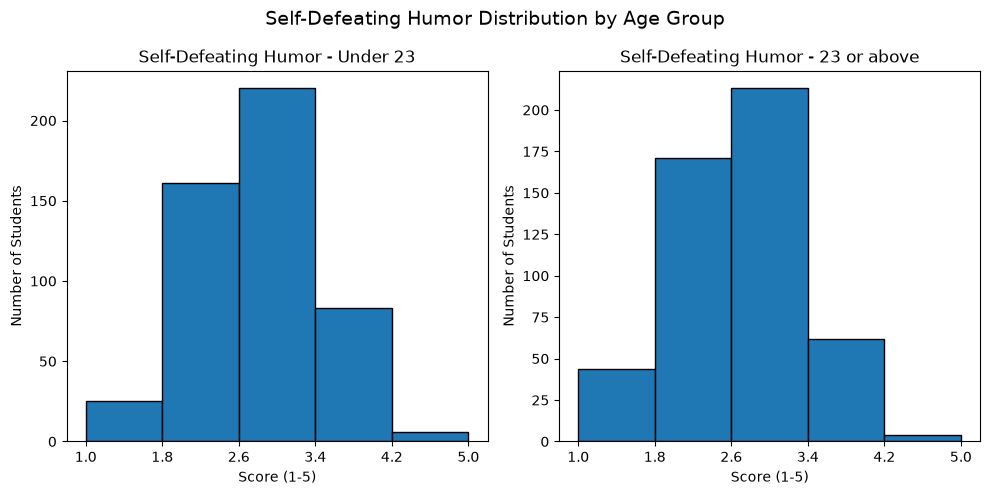

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# We will have two histograms side by side representing self-defeating and self-enhancing by age groups that we made earlier. 
# Two graphs per type of behavior

for i, age_group in enumerate(['Under 23', '23 or above']):
    subset = df_clean[df_clean['age_group'] == age_group]
    axes[i].hist(subset['selfdefeating'], bins=5, range=(1, 5), edgecolor='black')
    axes[i].set_title(f'Self-Defeating Humor - {age_group}')
    axes[i].set_xlabel('Score (1-5)')
    axes[i].set_ylabel('Number of Students')
    axes[i].set_xticks([1, 1.8, 2.6, 3.4, 4.2, 5]) # these points lets us get a more cleaner graph. 

plt.suptitle('Self-Defeating Humor Distribution by Age Group', fontsize=14)
plt.tight_layout()
plt.show()

## Descriptive Statistical Observations (Self-Defeating Humor by Age Group)

Self-Defeating Humor — Under 23

This histogram shows a right skewed distribution with a clear peak in the 2.6-3.4 bin at approximately 220 respondents, followed by the 1.8-2.6 bin at approximately 160 respondents. The center of the distribution is approximately in the 2.6-3.4 bin, suggesting a moderate mean and median around 2.7-3.0. The spread is moderate — most respondents fall between 1.8 and 3.4, with the distribution thinning out beyond that range. There are no significant outliers, though the 4.2-5.0 bin contains very few respondents which could be considered a mild high-end extreme.

Self-Defeating Humor — 23 or Above

This histogram also shows a right skewed distribution with a peak in the 2.6-3.4 bin at approximately 210 respondents, followed by the 1.8-2.6 bin at approximately 170 respondents. The center is approximately in the same range as the younger group, around 2.7-3.0. The spread is similar, with most respondents concentrated between 1.8 and 3.4. There are no significant outliers, though the 4.2-5.0 bin again contains very few respondents.

Comparing the Two Groups

Both distributions are right skewed and share similar centers, spreads, and outlier patterns. The older group shows a slightly larger proportion in the 1.0-1.8 bin (~45 vs ~25), suggesting marginally more older respondents score at the lowest end of self-defeating humor. This visual difference is subtle and requires formal statistical testing to confirm.

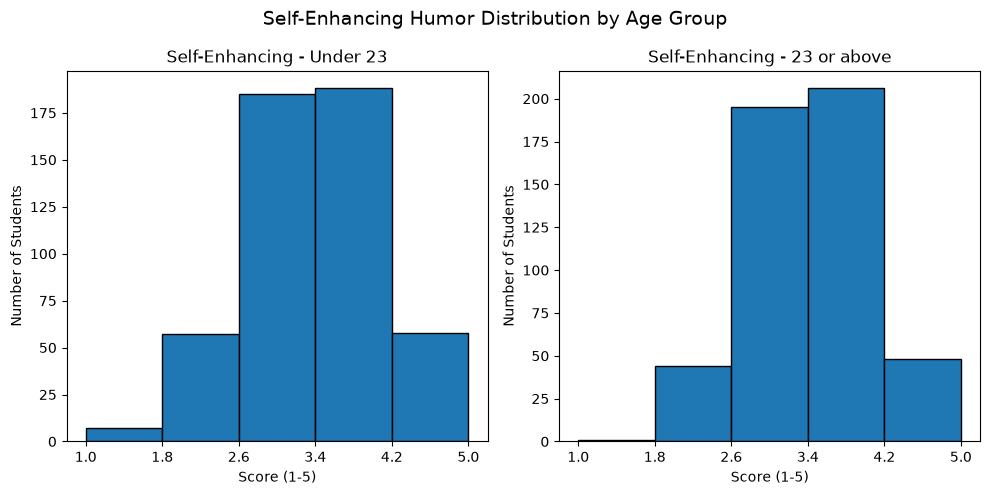

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, age_group in enumerate(['Under 23', '23 or above']):
    subset = df_clean[df_clean['age_group'] == age_group]
    axes[i].hist(subset['selfenhancing'], bins=5, range=(1, 5), edgecolor='black')
    axes[i].set_title(f'Self-Enhancing - {age_group}')
    axes[i].set_xlabel('Score (1-5)')
    axes[i].set_ylabel('Number of Students')
    axes[i].set_xticks([1, 1.8, 2.6, 3.4, 4.2, 5])

plt.suptitle('Self-Enhancing Humor Distribution by Age Group', fontsize=14)
plt.tight_layout()
plt.show()

## Descriptive Statistical Observations (Self-Enhancing humor by Age Group)

Self-Enhancing Humor — Under 23

This histogram shows an approximately normal distribution with peaks in the 2.6-3.4 and 3.4-4.2 bins, both at approximately 185 respondents. The center is approximately in the 3.0-3.5 range, suggesting a moderate mean and median. The spread is moderate — most respondents fall between 2.6 and 4.2, with relatively few at the extremes. There are no significant outliers, though the 1.0-1.8 bin contains very few respondents (~8), representing a mild low-end extreme.

Self-Enhancing Humor — 23 or Above

This histogram shows a similar approximately normal distribution with peaks in the 2.6-3.4 and 3.4-4.2 bins at approximately 195 and 205 respondents respectively. The center is approximately in the same range as the younger group, around 3.0-3.5. The spread is slightly narrower, with more respondents concentrated in the middle bins and fewer at the extremes. There are no significant outliers in this group.

Comparing the Two Groups

Both age groups show similar self-enhancing humor distributions with comparable centers and spreads. The older group appears slightly more concentrated in the middle range, suggesting marginally stronger and more consistent self-enhancing humor tendencies. This is consistent with a possible interpretation that older respondents use humor more effectively as a coping mechanism, though formal testing is required to confirm.

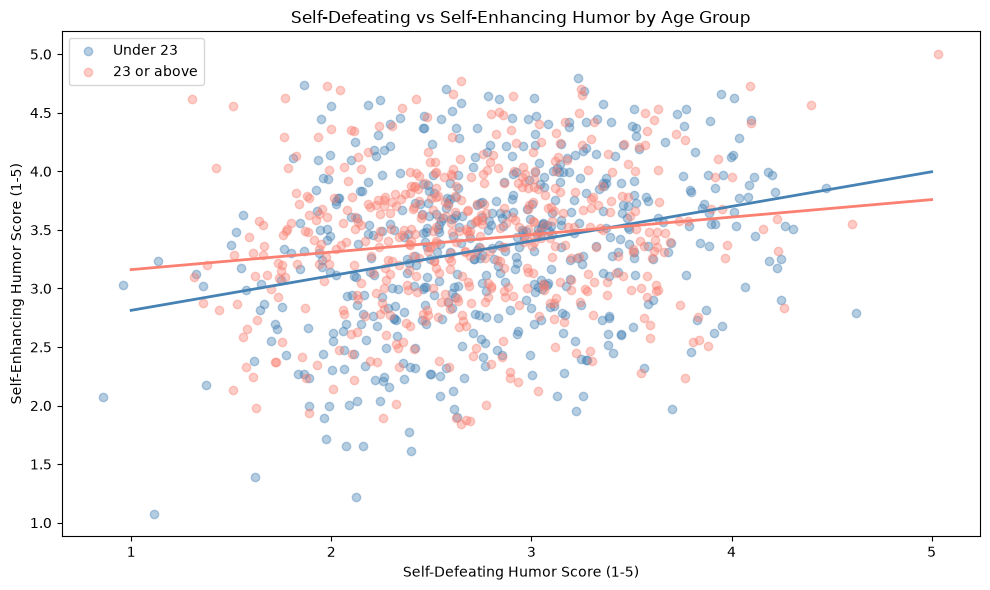

In [14]:
# Self- Enhancing behavior vs Self-Defeating behavior
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

colors = {'Under 23': 'steelblue', '23 or above': 'salmon'}

for age_group in ['Under 23', '23 or above']:
    subset = df_clean[df_clean['age_group'] == age_group]
    
    # Add jitter
    jitter_x = subset['selfdefeating'] + np.random.uniform(-0.15, 0.15, size=len(subset))
    jitter_y = subset['selfenhancing'] + np.random.uniform(-0.15, 0.15, size=len(subset))
    
    # Scatter plot
    ax.scatter(jitter_x, jitter_y, color=colors[age_group], label=age_group, alpha=0.4)
    
    # Regression line
    m, b = np.polyfit(subset['selfdefeating'], subset['selfenhancing'], 1)
    x_line = np.linspace(1, 5, 100)
    ax.plot(x_line, m * x_line + b, color=colors[age_group], linewidth=2)

ax.set_xlabel('Self-Defeating Humor Score (1-5)')
ax.set_ylabel('Self-Enhancing Humor Score (1-5)')
ax.set_title('Self-Defeating vs Self-Enhancing Humor by Age Group')
ax.legend()
plt.tight_layout()
plt.show()

## Descriptive statistical Analysis (Self Enhancing vs Self Defeating behaviors)

In this scatter plot, both regression lines slope upward, indicating a weak, positive, and linear relationship between self-defeating and self-enhancing humor for both age groups. The younger group (under 23) shows a steeper regression line, suggesting a stronger association between the two variables compared to the older group. The majority of points cluster around 3.0 for self-defeating humor and 3.5 for self-enhancing humor. This is unexpected, as we originally theorized that self-defeating humor replaces healthy self-enhancing humor — meaning people high in self-defeating humor should be low in self-enhancing humor. However, this data shows the opposite: they tend to move together, and people who score high on one tend to score high on the other. Very few respondents scored at the extreme high end (4.5-5.0) for either variable. A note on jitter: a small random offset was applied to data points to prevent overplotting, as all variables are ordinal with values 1-5. This does not alter the underlying data or statistical results.